
## 📖 **Dataset Introduction**

The **Algerian Forest Fires Dataset** contains meteorological and fire weather observations collected from two regions of Algeria: **Bejaia** and **Sidi-Bel Abbes**. The data was recorded during **June, July, August, and September of 2012**.

The primary objective of this dataset is to predict whether a forest fire will occur based on weather conditions and fire weather indices. Therefore, it is commonly used for **classification** tasks in machine learning.

The dataset includes weather-related features such as **temperature, relative humidity, wind speed, and rainfall**, along with several **Fire Weather Index (FWI)** components that describe the fire risk under different environmental conditions.

Since the records are collected from two different regions, we add a new **Region** column during preprocessing to identify the region associated with each observation.

---

## 📊 Dataset Features

| Feature         | Description                                                                       |
| --------------- | --------------------------------------------------------------------------------- |
| **day**         | Day of the month                                                                  |
| **month**       | Month when the observation was recorded                                           |
| **year**        | Year of observation (2012)                                                        |
| **Temperature** | Temperature in degrees Celsius (°C)                                               |
| **RH**          | Relative Humidity (%)                                                             |
| **Ws**          | Wind Speed (km/h)                                                                 |
| **Rain**        | Rainfall (mm)                                                                     |
| **FFMC**        | Fine Fuel Moisture Code                                                           |
| **DMC**         | Duff Moisture Code                                                                |
| **DC**          | Drought Code                                                                      |
| **ISI**         | Initial Spread Index                                                              |
| **BUI**         | Build-Up Index                                                                    |
| **FWI**         | Fire Weather Index                                                                |
| **Classes**     | Target variable indicating whether a fire occurred (`fire` or `not fire`)         |
| **Region**      | Region identifier added during preprocessing (`0` = Bejaia, `1` = Sidi-Bel Abbes) |



In [ ]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# The first row of this CSV does not contain the actual column names.
# Therefore, we use header=1 so that Pandas treats the second row as the header.

dataset = pd.read_csv("/content/drive/MyDrive/AI New folder/Algerian_forest_fires_dataset_UPDATE.csv", header=1)

In [ ]:
# Display the first few rows of the DataFrame to get an initial look at the data
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [ ]:
# Display a concise summary of the DataFrame, including data types and non-null values
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


Most columns are currently stored as object data type. Numerical columns should be converted to appropriate numeric data types (integer or float) before performing analysis or machine learning.



# **Data Cleaning**

In [ ]:
# missing value
dataset.isnull().sum()

,0
day,0
month,1
year,1
Temperature,1
RH,1
Ws,1
Rain,1
FFMC,1
DMC,1
DC,1


In [ ]:
# missing value (columns)
dataset[dataset.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


* `dataset.isnull()` creates a Boolean DataFrame indicating missing values.
* `any(axis=1)` checks each **row** and returns `True` if at least one value in that row is missing.
* `dataset[...]` filters and displays only those rows that contain missing values.


## **Adding a New Region Column**

The dataset contains forest fire records collected from **two different regions of Algeria**:

- **Bejaia Region** → Rows from index **0 to 122**
- **Sidi-Bel Abbes Region** → Rows from index **123 onwards**

To make the dataset easier to analyze, we create a new column named **Region**. This column identifies the region to which each record belongs.

We encode the regions as:

- **0** → Bejaia Region
- **1** → Sidi-Bel Abbes Region

Adding this feature makes it easier to perform region-wise analysis, visualization, and machine learning tasks.

In [ ]:
# Add a new column named 'Region'
dataset.loc[:122, "Region"] = 0          # Bejaia Region
dataset.loc[123:, "Region"] = 1          # Sidi-Bel Abbes Region

# Create a copy of the dataset
df = dataset.copy()

In [ ]:
# Convert the Region column to integer
df["Region"] = df["Region"].astype("int64")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
 14  Region       246 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 29.0+ KB


After creating the Region column, Pandas assigns the data type float64 by default. We convert it to int64 because the column contains only integer values (0 and 1).

In [ ]:
# Display the first five rows of the dataset
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
# Count the number of missing values in each column
df.isnull().sum()

,0
day,0
month,1
year,1
Temperature,1
RH,1
Ws,1
Rain,1
FFMC,1
DMC,1
DC,1


Before performing data cleaning, it is important to identify columns that contain missing values. The `isnull().sum()` method returns the total number of missing values in each column.

In [ ]:
# Remove rows containing missing values and reset the index
df = df.dropna().reset_index(drop=True)

The `dropna()` method removes all rows that contain one or more missing values `(NaN)`.

After removing these rows, the index may no longer be continuous. Therefore, `reset_index(drop=True)` is used to create a new sequential index starting from 0 while discarding the old index.

In [ ]:
# Verify that there are no missing values remaining
df.isnull().sum()

,0
day,0
month,0
year,0
Temperature,0
RH,0
Ws,0
Rain,0
FFMC,0
DMC,0
DC,0


## Remove the Duplicate Header Row
**bold text**
After removing the missing values, the dataset still contains one unnecessary row at **index 122**.

This row is not an actual data record. Instead, it contains the column names repeated as data because the original dataset combines records from two different regions.

To ensure the dataset contains only valid observations, we remove this duplicate header row and reset the index.

In [ ]:
# Display row 122 to verify its contents
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


We inspect row 122 because it appears to contain the column names instead of actual data values. This confirms that the row is a duplicate header and should be removed.

In [ ]:
# Remove the duplicate header row and reset the index
df = df.drop(122).reset_index(drop=True)

The `drop(122`) method removes the duplicate header row at index 122.

After removing the row, `reset_index(drop=True)` creates a new sequential index starting from **0**, ensuring that the dataset remains clean and well-structured.

In [ ]:
# Display row 122 after removing the duplicate header row
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,01,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [ ]:
# Display all column names
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

We display the column names to inspect their formatting and check for any unnecessary leading or trailing spaces.

In [ ]:
# Remove leading and trailing spaces from column names
df.columns = df.columns.str.strip()

Sometimes, column names contain unwanted spaces due to the way the dataset was created or exported. The `str.strip()` method removes these leading and trailing spaces, resulting in clean and consistent column names.

In [ ]:
# Display the updated column names
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

## **Check current data types**

In [ ]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    object
 1   month        243 non-null    object
 2   year         243 non-null    object
 3   Temperature  243 non-null    object
 4   RH           243 non-null    object
 5   Ws           243 non-null    object
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 28.6+ KB


In [ ]:
# Convert the required columns to integer data type
df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']] = \
df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']].astype('int64')

These columns contain whole-number values, so converting them to the int64 data type ensures that they are stored correctly and can be used efficiently for analysis and machine learning.

In [ ]:
# Verify the updated data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    int64 
 1   month        243 non-null    int64 
 2   year         243 non-null    int64 
 3   Temperature  243 non-null    int64 
 4   RH           243 non-null    int64 
 5   Ws           243 non-null    int64 
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int64 
dtypes: int64(7), object(8)
memory usage: 28.6+ KB


In [ ]:
# Identify columns with the object data type
object_columns = [column for column in df.columns if df[column].dtype == "O"]

object_columns

['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']

Identifies all columns with the object data type. These columns may contain text values or numerical values stored as strings.

In [ ]:
# Convert numeric object columns to float, excluding the target column
for column in object_columns:
    if column != "Classes":
        df[column] = df[column].astype("float64")

Most of the object-type columns contain numerical values stored as strings. We convert these columns to the float64 data type.

The **Classes** column is excluded because it contains categorical labels (fire and not fire), not numerical values.

### Why don't we convert `Classes`?

> The **Classes** column is a **categorical feature (target variable)** that contains class labels such as **`fire`** and **`not fire`**. Since these are text categories rather than numerical values, we do not convert this column to a numeric data type at this stage. It will be encoded later during data preprocessing before training the machine learning model.
**bold text**

In [ ]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


# **Lets save the clean dataset**

In [ ]:
# Save the cleaned dataset as a CSV file
df.to_csv("Algerian_forest_fires_cleaned_dataset.csv", index=False)

After completing the data cleaning and preprocessing steps, we save the cleaned dataset as a new CSV file. This allows us to reuse the processed data without repeating the cleaning steps in future analyses or machine learning projects.

Setting `index=False` prevents the DataFrame index from being saved as an additional column in the CSV file.

# **Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA) is the process of exploring and understanding a dataset before building a machine learning model.

The main objectives of EDA are:

- Understand the structure of the dataset.
- Analyze the distribution of individual features.
- Identify relationships between variables.
- Detect patterns, trends, and anomalies.
- Discover potential issues such as skewness, outliers, or multicollinearity.

EDA helps us gain valuable insights into the data and guides us in selecting appropriate preprocessing techniques and machine learning algorithms.

In [ ]:
# Create a copy of the cleaned dataset for exploratory data analysis
df_copy = df.copy()

Creates an independent copy, allowing you to perform EDA without affecting the original cleaned dataset.

In [ ]:
# Display the first five rows of the copied dataset
df_copy.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [ ]:
# Remove the date-related columns for exploratory analysis
df_copy.drop(['day', 'month', 'year'], axis=1, inplace=True)

In [ ]:
df_copy.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


## **Encoding of the Categories in classes**

**Encoding the Target Variable**

The **Classes** column is the target variable in this dataset. It contains two categorical values:

- **not fire** → Indicates that no forest fire occurred.
- **fire** → Indicates that a forest fire occurred.

Machine learning algorithms work with numerical data rather than text labels. Therefore, we encode these categories into numerical values:

- **0** → not fire
- **1** → fire

This process is known as **Label Encoding**, where each category is replaced with a unique numerical value.

In [ ]:
# Ensure 'Classes' column is of string type before applying .str accessor
df_copy["Classes"] = df_copy["Classes"].astype(str)

# Remove leading/trailing spaces and convert text to lowercase
df_copy["Classes"] = df_copy["Classes"].str.strip().str.lower()

# Encode the target variable
df_copy["Classes"] = np.where(df_copy["Classes"] == "not fire", 0, 1)

### **Explanation**

> The `np.where()` function performs conditional encoding.
>
> * If the value in the **Classes** column is **"not fire"**, it is replaced with **0**.
> * Otherwise, the value is replaced with **1**, representing **"fire"**.
>
> This converts the target variable from categorical values to numerical values, making it suitable for machine learning models.

Also use `str.contains` instead of `str.strip()`

**Verify the encoding**

In [ ]:
# Display the first five rows
df_copy.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [ ]:
# Check the unique values in the target column
df_copy["Classes"].unique()

array([0, 1])


> The `unique()` method returns all distinct values present in the **Classes** column.
>
> Since we encoded the target variable as:
>
> * **0 → not fire**
> * **1 → fire**
>
> the expected output should be:

```python
array([0, 1])
```

This confirms that the categorical values (`fire` and `not fire`) have been successfully converted into numerical values.


In [ ]:
# Count the number of samples in each class
df_copy["Classes"].value_counts()

,count
Classes,
1,137
0,106


> The `value_counts()` method counts how many times each unique value appears in the **Classes** column.
>
> After encoding, it displays the number of observations belonging to each class.

For example:

```text
1    137
0    106
```

This means:

* **137** observations belong to the **fire** class (`1`).
* **106** observations belong to the **not fire** class (`0`).

## **Distribution of Numerical Features**

Before building a machine learning model, it is important to understand the distribution of each numerical feature.

Histograms help us:

- Understand the distribution of data.
- Identify whether a feature follows a normal distribution.
- Detect skewness (left-skewed or right-skewed).
- Identify possible outliers.
- Decide whether feature transformations are required.

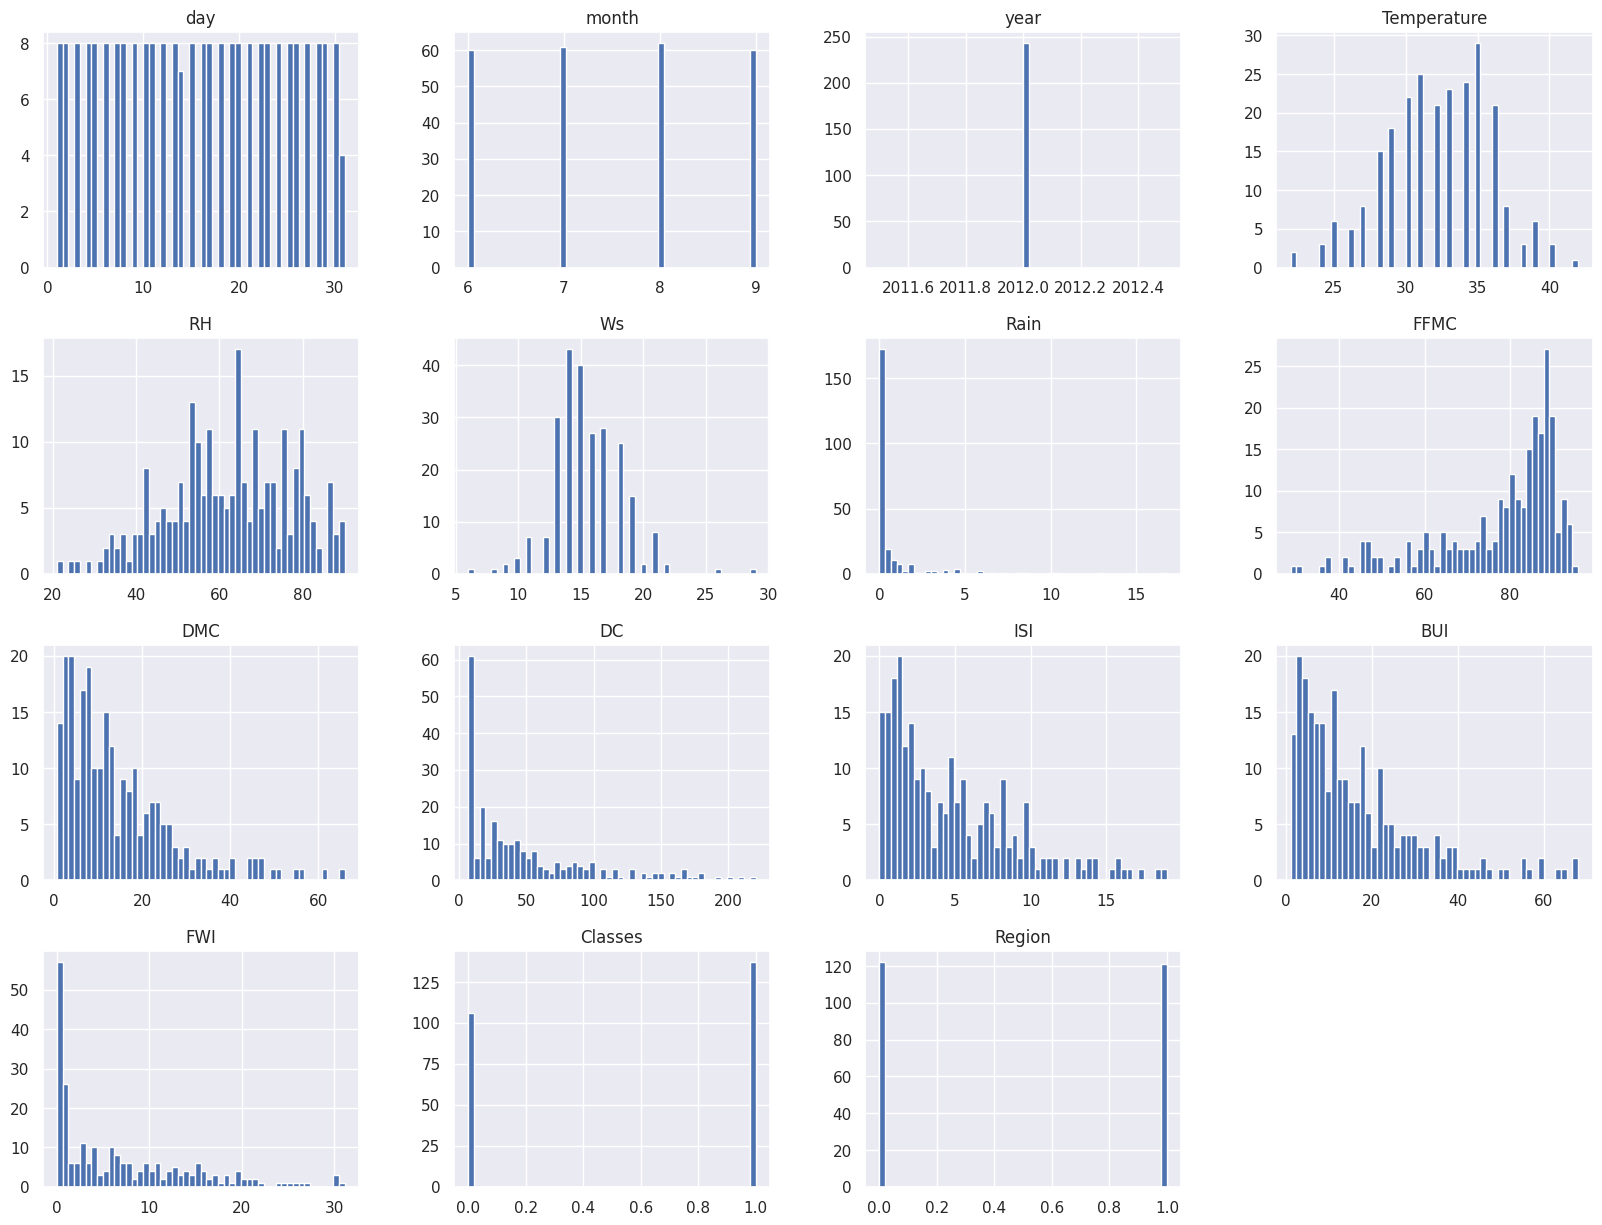

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the default plotting style
sns.set_theme()

# Plot histograms for all numerical features
df_copy.hist(bins=50, figsize=(20, 15))

plt.show()

> The `hist()` function creates a histogram for each numerical feature in the dataset.
>
> A histogram shows how the values of a feature are distributed across different ranges (bins).
>
> This helps us understand:
>
> * The shape of the distribution.
> * Whether the feature is normally distributed.
> * Whether the data is left-skewed or right-skewed.
> * Whether any unusual values (outliers) may exist.

> **Observation:**
>
> * Most numerical features exhibit either **left-skewed** or **right-skewed** distributions.
> * Only a few features appear to follow an approximately **normal distribution**.
> * This indicates that some features may require transformation or scaling before training a machine learning model.

## **Class Distribution**

**Percentage Distribution of Target Classes**

Next, we examine the distribution of the target variable (**Classes**).

Understanding the class distribution helps us determine whether the dataset is balanced or imbalanced, which is an important factor when building classification models.


In [ ]:
# Calculate the percentage of each class
df_copy['Classes'].value_counts(normalize=True)*100

,proportion
Classes,
1,56.378601
0,43.621399


## **Explanation**

> The `value_counts()` method counts the number of observations in each class.
>
> Setting `normalize=True` converts these counts into proportions.
>
> Multiplying by **100** converts the proportions into percentages.

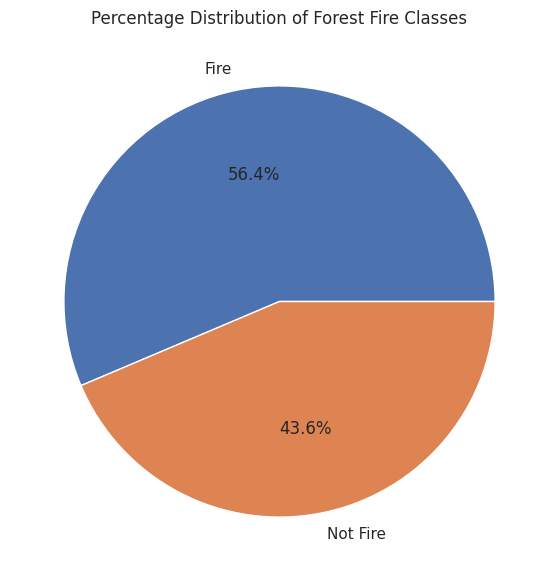

In [ ]:
import matplotlib.pyplot as plt

# Labels for the target classes
class_labels = ["Fire", "Not Fire"]

# Calculate the percentage of each class
percentage = df_copy['Classes'].value_counts(normalize=True) * 100

# Plot the percentage distribution of the target classes
plt.figure(figsize=(12, 7))

plt.pie(
    percentage,
    labels=class_labels,
    autopct="%1.1f%%"
)

plt.title("Percentage Distribution of Forest Fire Classes")

plt.show()

### **Explanation**

> A pie chart provides a visual representation of the percentage of observations belonging to each target class.
>
> This allows us to quickly determine whether the dataset contains a balanced number of **Fire** and **Not Fire** observations.

---

### **Key Observation**

Write something like:

> **Observation:**
>
> * The dataset contains observations from both **Fire** and **Not Fire** classes.
> * The class distribution is reasonably balanced, indicating that the dataset is suitable for building a binary classification model.
> * A balanced dataset reduces the likelihood of the model becoming biased toward one class.


# **Correlation**

In [ ]:
df_copy.corr()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
day,1.000000,-0.000369,NaN,0.097227,-0.076034,0.047812,-0.112523,0.224956,0.491514,0.527952,0.180543,0.517117,0.350781,0.202840,0.000821
month,-0.000369,1.000000,NaN,-0.056781,-0.041252,-0.039880,0.034822,0.017030,0.067943,0.126511,0.065608,0.085073,0.082639,0.024004,0.001857
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature,0.097227,-0.056781,NaN,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.076034,-0.041252,NaN,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,0.047812,-0.039880,NaN,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.112523,0.034822,NaN,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.224956,0.017030,NaN,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.491514,0.067943,NaN,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.527952,0.126511,NaN,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734


## **Key Observations**

> * Several Fire Weather Index (FWI) components (**DMC, DC, BUI, ISI, and FWI**) are strongly positively correlated with one another.
> * **Temperature** is negatively correlated with **Relative Humidity**, indicating that hotter conditions are generally associated with lower humidity.
> * **FFMC**, **ISI**, and **FWI** show the strongest positive correlation with the target variable (**Classes**), making them potentially important features for predicting forest fires.
> * **Wind Speed** and **Region** exhibit relatively weak correlations with the target variable.


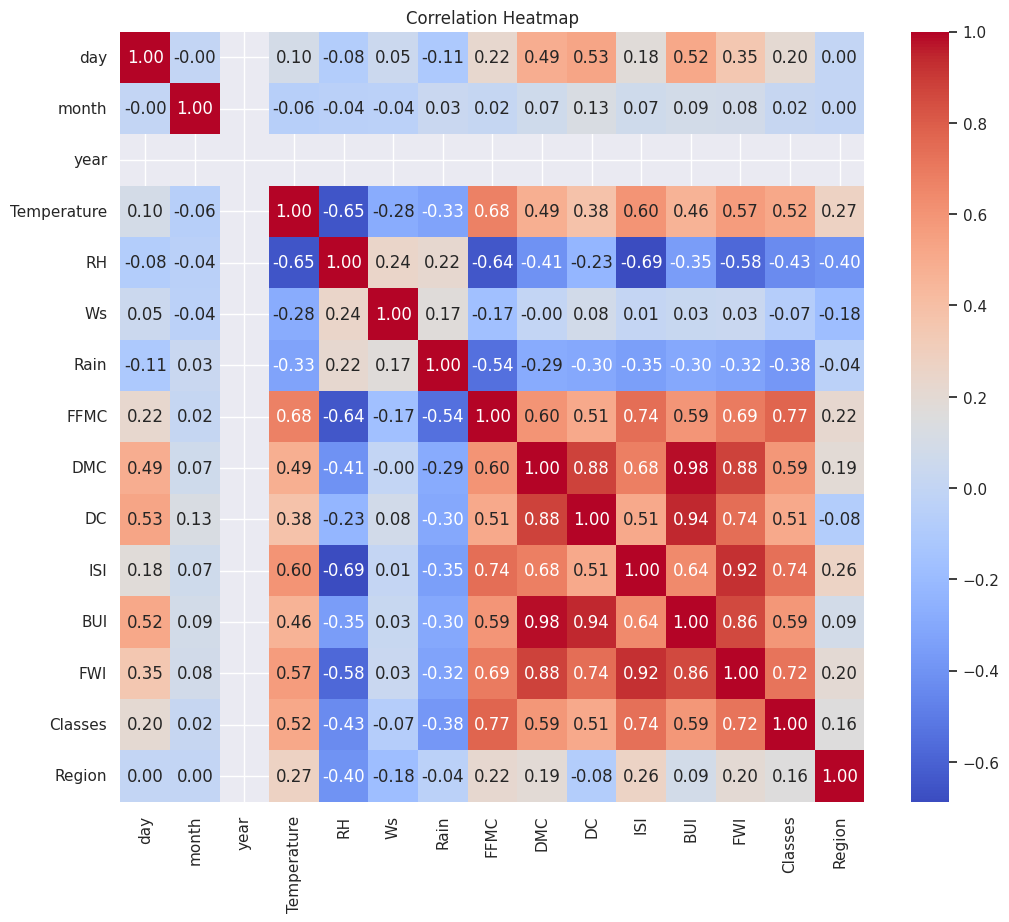

In [ ]:
# Plot the correlation heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    df_copy.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# **Detecting Outliers Using a Box Plot**

**Outlier Detection Using a Box Plot**

A box plot is a statistical visualization used to identify the distribution of a numerical feature and detect potential outliers.

It displays:

- Minimum value
- First Quartile (Q1)
- Median (Q2)
- Third Quartile (Q3)
- Maximum value
- Potential outliers

Outliers are data points that lie significantly above or below the majority of the observations.

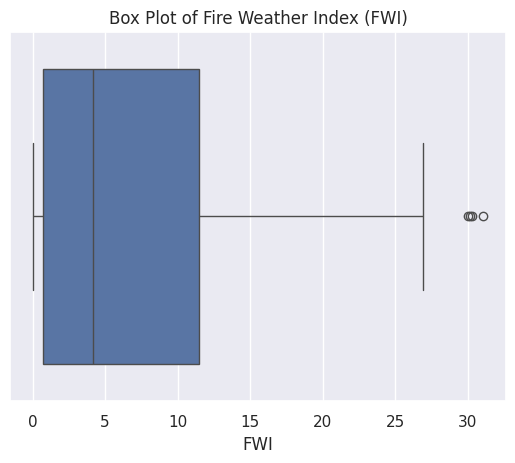

In [ ]:
# Plot a box plot to detect outliers in the Fire Weather Index (FWI)
sns.boxplot(x=df_copy["FWI"])

plt.title("Box Plot of Fire Weather Index (FWI)")
plt.xlabel("FWI")

plt.show()

## Explanation

> The box plot helps visualize the distribution of the **Fire Weather Index (FWI)** and identifies potential outliers.
>
> The main components of a box plot are:
>
> * **Median (Q2):** The horizontal line inside the box represents the middle value of the data.
> * **First Quartile (Q1):** The left edge of the box represents the 25th percentile.
> * **Third Quartile (Q3):** The right edge of the box represents the 75th percentile.
> * **Whiskers:** Extend to the smallest and largest values within **1.5 × IQR**.
> * **Outliers:** Individual points beyond the whiskers are considered potential outliers.

---

**How are outliers detected?**

The **Interquartile Range (IQR)** is calculated as:

IQR = Q3 - Q1


Any observation outside the following range is considered a potential outlier:

* **Lower Bound = Q1 − 1.5 × IQR**
* **Upper Bound = Q3 + 1.5 × IQR**

---

If your box plot shows only a few points outside the whiskers, you can write:

> **Observation:**
>
> * The **FWI** feature contains a few potential outliers.
> * These outliers represent unusually high or low Fire Weather Index values.
> * Outliers should not be removed automatically, as they may represent genuine extreme weather conditions that are important for predicting forest fires.

If there are no points outside the whiskers:

> **Observation:**
>
> * The **FWI** feature does not contain significant outliers.
> * Most observations fall within the expected range of the data.

## **Monthly Forest Fire Analysis**

In this analysis, we examine the monthly distribution of **Fire** and **Not Fire** cases for the **Bejaia Region**.

The objective is to understand how the occurrence of forest fires varies across different months and identify the periods with the highest fire activity.

`df_copy` no longer contains the **day**, **month**, and **year** columns because they were removed earlier during EDA.

Since we need the **month** column for this analysis, we use the original cleaned dataset (`df`).

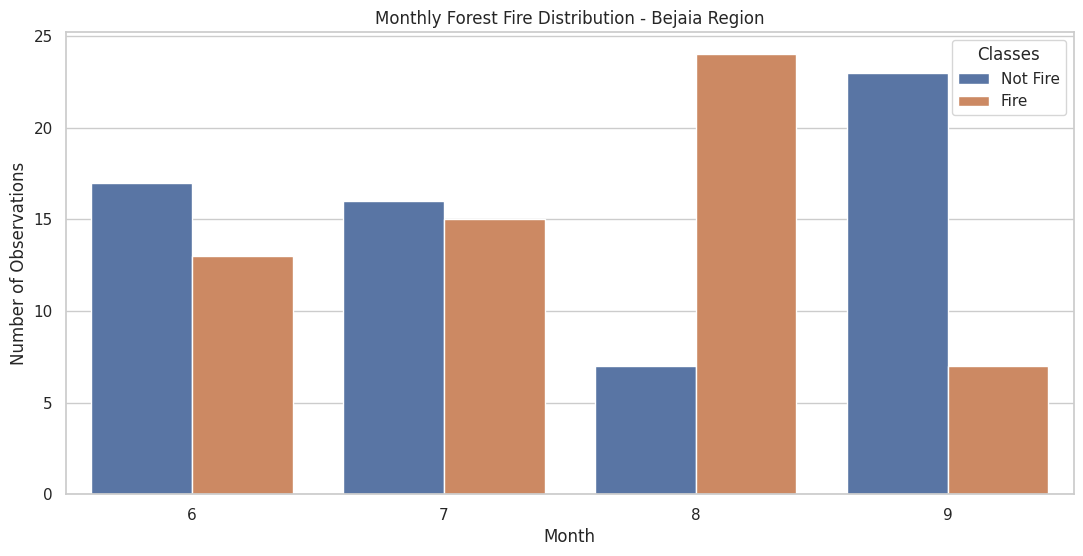

In [ ]:
# Create a temporary copy of the cleaned dataset for visualization.
# This ensures that the original dataset remains unchanged while
# converting the encoded target labels back to categorical values.

df_plot = df.copy()

# Convert the Classes column to string and standardize the text
df_plot["Classes"] = (
    df_plot["Classes"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Convert the target labels back to descriptive categories
df_plot["Classes"] = np.where(
    df_plot["Classes"] == "not fire",
    "Not Fire",
    "Fire"
)

# Filter the dataset for the Bejaia Region
df_temp = df_plot[df_plot["Region"] == 0]

# Set the plotting style
sns.set_style("whitegrid")

# Create the figure
plt.figure(figsize=(13, 6))

# Plot the monthly distribution of Fire and Not Fire cases
sns.countplot(
    x="month",
    data=df_temp,
    hue="Classes"
)

# Add chart title and labels
plt.title("Monthly Forest Fire Distribution - Bejaia Region")
plt.xlabel("Month")
plt.ylabel("Number of Observations")

plt.show()

## **Explanation**

> The `countplot()` function displays the number of observations for each month, grouped by the **Classes** column (`Fire` and `Not Fire`).
>
> This visualization helps us compare the frequency of forest fire incidents across different months and identify seasonal trends.

---

**Observation**

After looking at your plot, you can write something like:

> * Forest fire incidents vary across different months.
> * Some months record significantly more fire cases than others, indicating seasonal variation in forest fire activity.
> * Such insights can help identify high-risk periods and support better fire prevention planning.


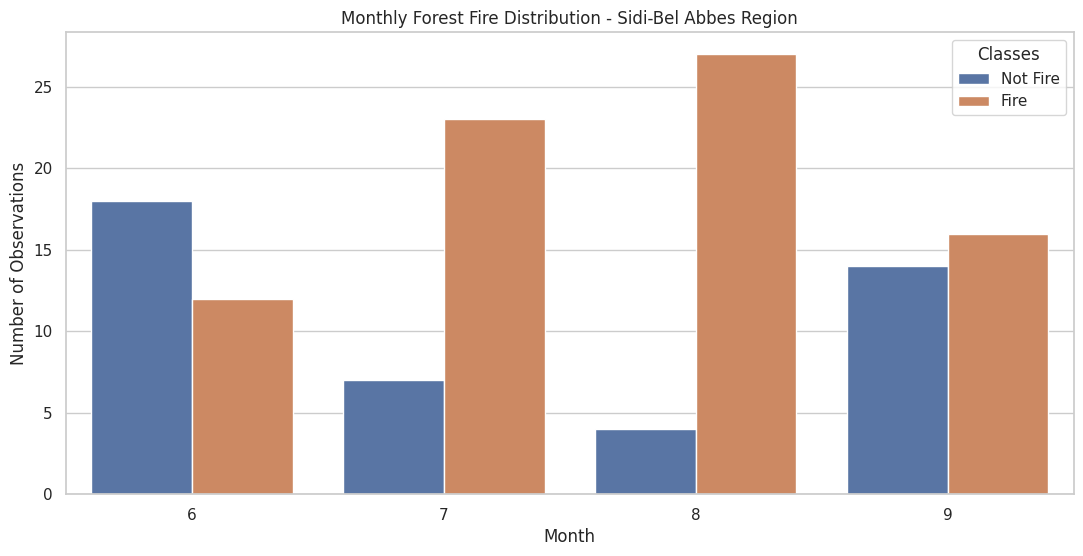

In [ ]:
# Convert the Classes column to string and standardize the text
df_plot["Classes"] = (
    df_plot["Classes"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Convert the target labels back to descriptive categories
df_plot["Classes"] = np.where(
    df_plot["Classes"] == "not fire",
    "Not Fire",
    "Fire"
)

# Filter the dataset for the Sidi-Bel Abbes Region (Region = 1)
df_temp = df_plot[df_plot["Region"] == 1]

# Set the plotting style
sns.set_style("whitegrid")

# Create the figure
plt.figure(figsize=(13, 6))

# Plot the monthly distribution of Fire and Not Fire cases
sns.countplot(
    x="month",
    data=df_temp,
    hue="Classes"
)

# Add chart title and axis labels
plt.title("Monthly Forest Fire Distribution - Sidi-Bel Abbes Region")
plt.xlabel("Month")
plt.ylabel("Number of Observations")

# Display the plot
plt.show()

Its observed that August and September had the most number of forest fires for both regions. And from the above plot of months, we can understand few things

Most of the fires happened in August and very high Fires happened in only 3 months - June, July and August.

Less Fires was on September